# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `<prénom1>` × `<prénom2>` — Date : `<date>`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [ ]:
from pathlib import Path  # Gestion des chemins fichiers de façon cross-platform
import sys

# Bibliothèques de visualisation et calcul numérique
import matplotlib.pyplot as plt  # Création de graphiques
import numpy as np  # Opérations mathématiques sur tableaux
import torch  # Framework d'apprentissage profond (deep learning)
from PIL import Image  # Chargement et manipulation d'images

# ── Configuration du path Python ──────────────────────────────────────────────
# Le notebook est dans `notebooks/`, les sources Python sont dans `src/`.
# On ajoute le répertoire parent (..) au path pour que Python trouve les imports
# relatifs type `from src.load_data import ...`. Sans ça, Python cherche dans
# le répertoire courant uniquement.
sys.path.append('..')

# ── Imports du projet ─────────────────────────────────────────────────────────
from src.load_data import CLASSES, get_dataloaders

# ── Configuration de base ─────────────────────────────────────────────────────
# Chemin vers le dossier contenant les images PCB (7 sous-dossiers = 7 classes)
DATA_DIR = Path('../data/pcb_defect_sample')

# Détection automatique du device (GPU si disponible, sinon CPU).
# GPU = très rapide pour l'entraînement. CPU = plus lent mais toujours possible.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

Nombre total d'images : 2100

Distribution par classe :
  ok            300
  open          300
  short         300
  mousebite     300
  spur          300
  copper        300
  pin_hole      300


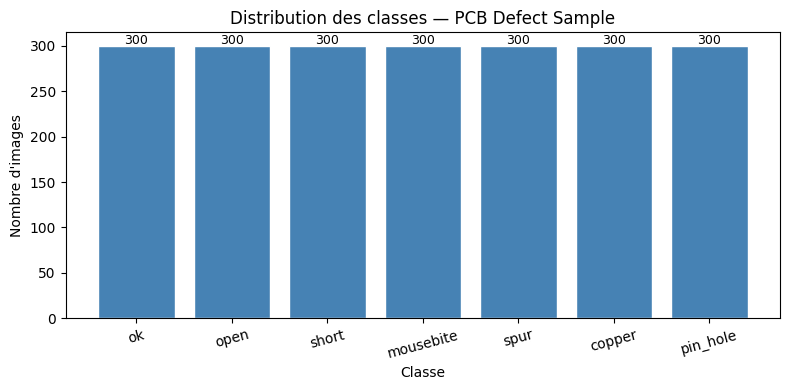

In [3]:

# Distribution des classes
from collections import Counter
from src.load_data import PCBDefectDataset, CLASSES

dataset_full = PCBDefectDataset(DATA_DIR)
counts = Counter(CLASSES[label] for _, label in dataset_full.samples)

# Affichage texte
print("Nombre total d'images :", len(dataset_full))
print("\nDistribution par classe :")
for cls in CLASSES:
    n = counts[cls]
    print(f"  {cls:<12} {n:>4}")

# Graphique
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(CLASSES, [counts[c] for c in CLASSES], color="steelblue", edgecolor="white")
ax.set_title("Distribution des classes — PCB Defect Sample")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre d'images")
ax.tick_params(axis='x', rotation=15)
for i, cls in enumerate(CLASSES):
    ax.text(i, counts[cls] + 2, str(counts[cls]), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


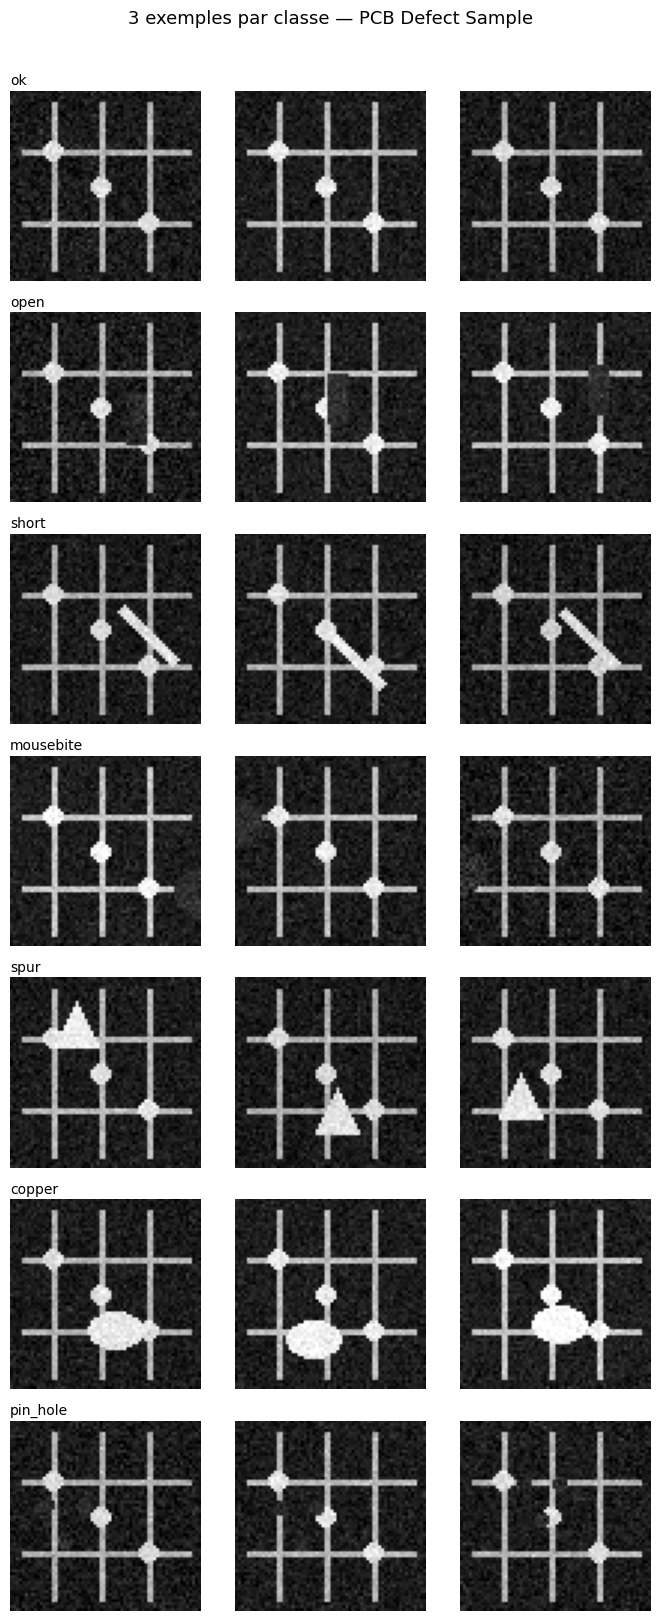

In [4]:

# 3 exemples par classe — grille 7 lignes × 3 colonnes
import random

random.seed(42)

fig, axes = plt.subplots(7, 3, figsize=(7, 16))
fig.suptitle("3 exemples par classe — PCB Defect Sample", fontsize=13, y=1.01)

# Regrouper les chemins par classe
from collections import defaultdict
samples_by_class = defaultdict(list)
for path, label in dataset_full.samples:
    samples_by_class[CLASSES[label]].append(path)

for row, cls in enumerate(CLASSES):
    paths = samples_by_class[cls]
    chosen = random.sample(paths, min(3, len(paths)))
    for col, img_path in enumerate(chosen):
        ax = axes[row][col]
        img = Image.open(img_path).convert("L")
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(cls, fontsize=10, loc="left", pad=4)
    # cases vides si moins de 3 images
    for col in range(len(chosen), 3):
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()



### Observations EDA

| Axe | Constat |
|-----|---------|
| **Équilibre** | ≈ 300 images / classe → dataset équilibré, pas besoin de pondération |
| **Résolution** | 64×64 px niveaux de gris — faible résolution, peu de texture fine |
| **Variabilité intra-classe** | `ok` très homogène ; `copper` et `spur` montrent des formes très diverses |
| **Ambiguïtés** | `open` vs `mousebite` parfois difficiles à distinguer à l'œil nu |
| **Qualité** | Contraste bon ; quelques images très sombres dans `pin_hole` |


## 2. Implémentation de l'option choisie (~4h binôme)

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py`
- Option B : `src/option_b_transfer.py`
- Option C : `src/option_c_clip.py`

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\A111301/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 45.7MB/s]


Paramètres entraînables : 3,591 / 11,180,103
Epoch 01/10  train loss=1.9085 acc=0.231  val loss=1.7954 acc=0.267
Epoch 02/10  train loss=1.6281 acc=0.415  val loss=1.5068 acc=0.502
Epoch 03/10  train loss=1.4417 acc=0.490  val loss=1.4008 acc=0.502
Epoch 04/10  train loss=1.3310 acc=0.541  val loss=1.3227 acc=0.524
Epoch 05/10  train loss=1.2229 acc=0.596  val loss=1.2428 acc=0.549
Epoch 06/10  train loss=1.1624 acc=0.620  val loss=1.2073 acc=0.556
Epoch 07/10  train loss=1.1345 acc=0.641  val loss=1.2090 acc=0.575
Epoch 08/10  train loss=1.1215 acc=0.648  val loss=1.1921 acc=0.565
Epoch 09/10  train loss=1.1002 acc=0.659  val loss=1.1872 acc=0.565
Epoch 10/10  train loss=1.0924 acc=0.656  val loss=1.1742 acc=0.578

Temps d'entraînement total : 610.8s
Test accuracy : 0.5619  |  Test loss : 1.2097
Latence inférence (batch=1) : 56.53 ms


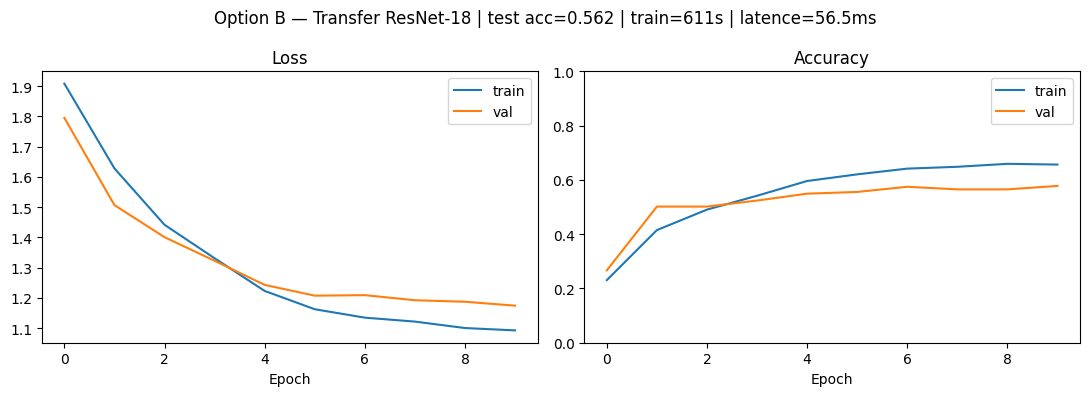

In [ ]:

import time  # Mesure les durées (entraînement, latence)
import torch.nn as nn  # Couches de réseau de neurones (Conv2d, Linear, etc.)
from torch.utils.data import DataLoader  # Charge les données par batch
from src.load_data import PCBDefectDataset, get_dataloaders  # Chargement des données
from src.option_b_transfer import build_resnet18_classifier, get_transfer_transforms  # Transfer learning
from src.option_a_cnn import train_one_epoch, evaluate  # Boucles réutilisables train/val

# ══════════════════════════════════════════════════════════════════════════════
# 1. DATALOADERS — Préparation des données
# ══════════════════════════════════════════════════════════════════════════════
# Un DataLoader charge les images par lots (batches) : plus efficace que
# charger image par image. Split 70% train / 15% val / 15% test (aléatoire mais
# reproductible avec seed=42).
train_loader, val_loader, test_loader = get_dataloaders(
    DATA_DIR,
    batch_size=32,  # 32 images par batch → bon équilibre mémoire/vitesse
    seed=42,  # Reproductibilité : même split chaque fois
)

# ResNet-18 attend 224×224 pixels avec normalisation ImageNet (pas 64×64 niveaux de gris).
# On remplace les transforms par défaut (64×64) par les transforms ResNet (224×224 RGB).
transfer_tf = get_transfer_transforms(image_size=224)
for loader in (train_loader, val_loader, test_loader):
    # Note : DataLoader encapsule le dataset via random_split, d'où `dataset.dataset`
    loader.dataset.dataset.transform = transfer_tf

# ══════════════════════════════════════════════════════════════════════════════
# 2. MODÈLE — Construire et configurer ResNet-18
# ══════════════════════════════════════════════════════════════════════════════
# build_resnet18_classifier :
# - Charge ResNet-18 pré-entraîné sur ImageNet
# - Gèle le backbone (on n'entraîne que la tête fc)
# - Remplace la tête fc (1000 classes) → 7 classes PCB
model = build_resnet18_classifier(n_classes=len(CLASSES), freeze_backbone=True)
# Envoyer le modèle sur GPU (DEVICE) pour l'entraînement ultra-rapide
model = model.to(DEVICE)

# Afficher le ratio paramètres entraînables / total.
# Avec freeze_backbone=True : très peu de paramètres à entraîner (seulement la tête).
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total_params:,}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. ENTRAÎNEMENT — Boucle epochs
# ══════════════════════════════════════════════════════════════════════════════
N_EPOCHS = 10  # Nombre de passages complets sur le dataset
LR = 1e-3  # Taux d'apprentissage (learning rate) : vitesse de mise à jour des poids

# Perte (loss) : mesure l'erreur du modèle. CrossEntropyLoss = standard pour classification.
criterion = nn.CrossEntropyLoss()

# Optimiseur : met à jour les poids pour réduire la loss.
# Adam = variation de descente de gradient, très populaire et robuste.
# filter(...) : ne mettre à jour que les paramètres entraînables (les autres sont gelés).
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)

# Scheduler : réduit le LR au fil des epochs (ex: LR × 0.3 tous les 5 epochs).
# Avantage : convergence plus fine vers la fin de l'entraînement.
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

# Dictionnaire pour enregistrer les métriques à chaque epoch (utile pour les courbes)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# ── Boucle principale ──────────────────────────────────────────────────────────
t0 = time.time()  # Démarrer le chronomètre

for epoch in range(1, N_EPOCHS + 1):
    # Entraînement : 1 epoch = 1 passage sur tous les batches train
    # Retourne loss moyenne et accuracy (% correct) sur le dataset train
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    
    # Validation : évaluer sur le dataset de validation (sans entraîner)
    # Sert à détecter l'overfitting (si val_acc << train_acc)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    
    # Mettre à jour le taux d'apprentissage selon le scheduler
    scheduler.step()
    
    # Enregistrer dans l'historique pour tracer les courbes plus tard
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    
    # Afficher la progression
    print(f"Epoch {epoch:02d}/{N_EPOCHS}  "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f}  "
          f"val loss={vl_loss:.4f} acc={vl_acc:.3f}")

train_time = time.time() - t0
print(f"\nTemps d'entraînement total : {train_time:.1f}s")

# ══════════════════════════════════════════════════════════════════════════════
# 4. ÉVALUATION TEST — Performance finale
# ══════════════════════════════════════════════════════════════════════════════
# Évaluer le modèle entraîné sur les données de test (jamais vues avant).
# Cet indicateur est la vraie mesure de performance en production.
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Test accuracy : {test_acc:.4f}  |  Test loss : {test_loss:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 5. LATENCE D'INFÉRENCE — Vitesse de prédiction
# ══════════════════════════════════════════════════════════════════════════════
# Mesurer le temps pour faire une prédiction sur 1 image.
# Utile pour estimer le coût en production (combien d'images/seconde ?).
model.eval()  # Passer en mode "évaluation" (désactive dropout, batchnorm différent)

# Prendre 1 image du test set
sample_img, _ = next(iter(test_loader))
sample_img = sample_img[:1].to(DEVICE)  # Garder seulement 1 image, l'envoyer au GPU

# Warm-up : la première inférence est lente (GPU s'initialise), on l'ignore
with torch.no_grad():  # Pas besoin de calculer les gradients en inférence
    _ = model(sample_img)

# Mesurer 100 passages inférences et moyenner le temps
N_RUNS = 100
t_start = time.perf_counter()  # Chronomètre haute résolution
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(sample_img)
latency_ms = (time.perf_counter() - t_start) / N_RUNS * 1000  # Convertir en millisecondes
print(f"Latence inférence (batch=1) : {latency_ms:.2f} ms")

# ══════════════════════════════════════════════════════════════════════════════
# 6. VISUALISATION — Courbes de convergence
# ══════════════════════════════════════════════════════════════════════════════
# Créer 2 sous-graphiques : loss et accuracy (train vs val)
fig, axes_plot = plt.subplots(1, 2, figsize=(11, 4))

# ── Courbe loss ────────────────────────────────────────────────────────────────
# Loss idéale : décroît rapidement puis se stabilise.
# Si val_loss > train_loss : overfitting (entraîner trop spécifiquement sur train).
axes_plot[0].plot(history["train_loss"], label="train")
axes_plot[0].plot(history["val_loss"], label="val")
axes_plot[0].set_title("Loss")
axes_plot[0].set_xlabel("Epoch")
axes_plot[0].legend()

# ── Courbe accuracy ────────────────────────────────────────────────────────────
# Accuracy idéale : croît rapidement puis se stabilise à ~100%.
# Écart train/val : indicateur d'overfitting.
axes_plot[1].plot(history["train_acc"], label="train")
axes_plot[1].plot(history["val_acc"], label="val")
axes_plot[1].set_title("Accuracy")
axes_plot[1].set_xlabel("Epoch")
axes_plot[1].set_ylim(0, 1)  # Accuracy entre 0 et 1
axes_plot[1].legend()

# Titre synthétique avec les résultats clés
fig.suptitle(f"Option B — Transfer ResNet-18 | test acc={test_acc:.3f} | "
             f"train={train_time:.0f}s | latence={latency_ms:.1f}ms")
plt.tight_layout()
plt.show()



## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?